In [81]:
# Objective: 
#  Estimate the medical insurance claim amount based on personal data. 

# Dataset: 
#  Medical Cost Personal Dataset 

# Instructions: 
#  Train a Linear Regression model to predict charges. 
#  Visualize how BMI, age, and smoking status impact insurance charges. 
#  Evaluate model performance using MAE and RMSE.

# importing pandas, matplotlib, seaborn, sklearn, Label Encoder, Train Test Split, Linear Regression, Mean Squared Error, and Mean Absolute error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [23]:
# loading insurance claim amount dataset 
df = pd.read_csv('insurance_claim_amount.csv')

In [24]:
# First 5 rows of dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Checking for null values in the dataset
df.isnull().sum()

In [32]:
df.duplicated().sum()

np.int64(0)

In [29]:
# removing duplicated rows
df.drop_duplicates(inplace=True)

In [ ]:
# checking for the number of categories in sex and region to identify which class will we use LabelEncoder of One-Hot Encoding.
df["sex"].unique()
df["region"].unique()

In [33]:
# storing LabelEncoder class into a variable
le = LabelEncoder()

# applying Label Encoder class on Sex and Smoker variable because they are nominal(string categorical)
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])

# applying One-Hot Encoder class on Region variable because it has more than 2 categories
df = pd.get_dummies(df, columns=["region"], drop_first=True)

Text(0, 0.5, 'Amount')

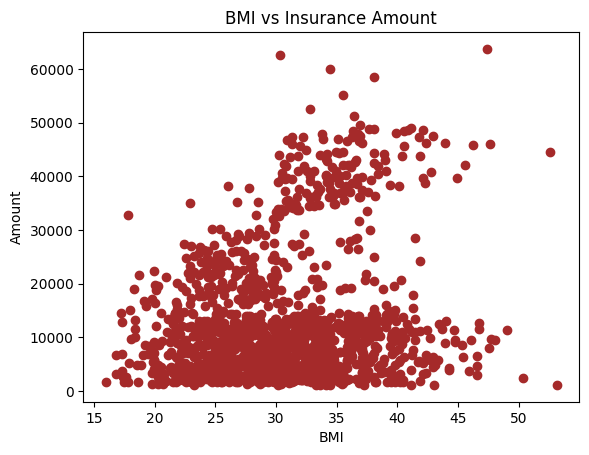

In [60]:
# Visualizing BMI vs Charges(Insurance Amount) relation using scatter plot

plt.scatter(df["bmi"], df["charges"], color="brown")
plt.title("BMI vs Insurance Amount")
plt.xlabel("BMI")
plt.ylabel("Amount")

Text(0, 0.5, 'Amount')

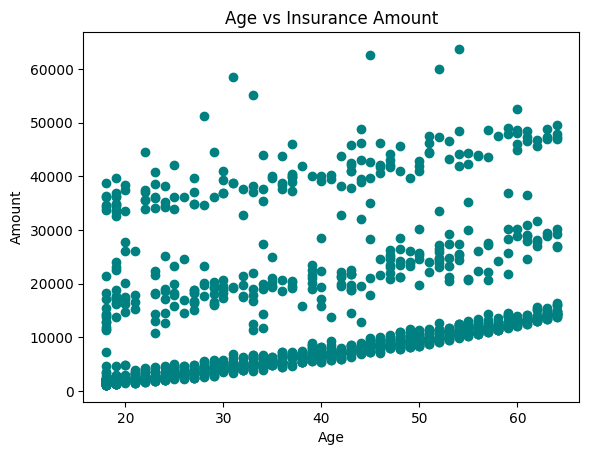

In [62]:
# Visualizing Age vs Charges(Insurance Amount) relation using scatter plot

plt.scatter(df["age"], df["charges"], color="teal")
plt.title("Age vs Insurance Amount")
plt.xlabel("Age")
plt.ylabel("Amount")

<Axes: xlabel='smoker', ylabel='charges'>

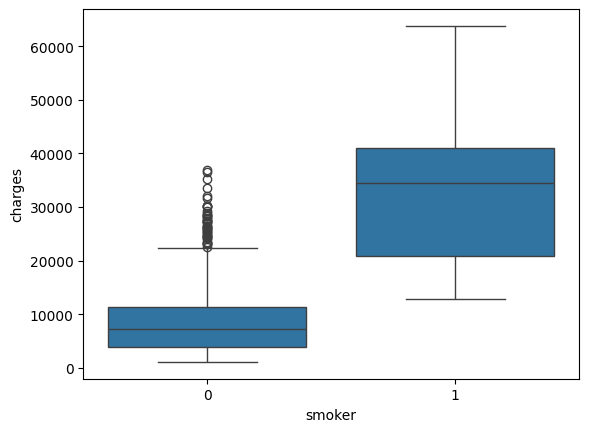

In [70]:
# Visualizing Smoker(smoke status) vs Charges(Insurance Amount) relation using seaborn box plot

sns.boxplot(x="smoker", y="charges", data=df)

In [73]:
# defining the X(independent variable) and y(target/dependent/predicting) varibale

X = df.drop("charges", axis=1)
y = df["charges"]

In [76]:
# splitting the data into Train and Test, the train and test split ratio is 0.8 means 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

In [78]:
# fitting Linear Regression model on the train data
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
# Predicting the model by passing X_test parameter and using predict function
y_pred = model.predict(X_test)
print(y_pred)

[ 7696.61218206  5406.57824801 14678.54585856 ...  6427.18744282
  8033.44580852 10188.52498143]


In [82]:
# calculating Mean Absolute Error(mae) and Mean Squared Error(mse) using mean absolute error and mean squared error functions
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)

Mean Absolute Error:  4116.312841592362
Mean Squared Error:  37013078.047929294
